In [ ]:
!pip install --quiet  -r req-fine-models.txt

In [ ]:
##Importante tener cuenta en hugging face, para algunos modelos como meta/llama
# se debe tener aprobacion para descargar desde la plataforma el modelo.
from huggingface_hub import login
login(new_session=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
import transformers
import re
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed,BitsAndBytesConfig,EarlyStoppingCallback
from peft import LoraConfig, get_peft_model,prepare_model_for_kbit_training
import random
from datasets import Dataset
from pathlib import Path
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm.auto import tqdm
DATA_RAW = Path("./data-sources/raw")
DATA_PREPR = Path("./data-sources/pre-processed")
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PREPR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

In [ ]:
df_train = pd.read_csv(DATA_PREPR/"data_finetuning_train.csv")
df_val = pd.read_csv(DATA_PREPR/"data_finetuning_val.csv")
#df_test = pd.read_csv(DATA_PREPR/"data_finetuning_test.csv")

print(f'Registros totales cargados para entrenamiento: {len(df_train)}')
print(f'Registros totales cargados para validacion: {len(df_val)}')
#print(f'Registros totales cargados para test: {len(df_test)}')

Registros totales cargados para entrenamiento: 3038
Registros totales cargados para validacion: 380


In [ ]:
def generar_prompt(cientific_text):
    input_text = f"""Using the following abstract of a biomedical study as input, generate a Plain Language Summary (PLS) understandable by any patient, regardless of their health literacy. Ensure that the generated text adheres to the following instructions which should be followed step-by-step:
    a. Specific Structure: the generated PLS should be presented in a logical order, using the following order:
        1. Plain Title
        2. Rationale
        3. Trial Design
        4. Results
    b. Sections should be authored following these parameters:
        1. Plain Title: Simplified title understandable to a layperson that summarizes the research that was done.
        2. Rationale: Include: background or study rationale providing a general description of the condition, what it may cause or why it is a burden for the patients; the reason and main hypothesis for the study; and why the study is needed, and why the study medication has the potential to treat the condition.
        3. Trial Design: Answer ‘How is this study designed?’ Include the description of the design, description of study and patient population (age, health condition, genre), and the expected amount of time a person will be in the study.
        4. Results: answer ‘What were the main results of the study’, include what are the benefits for the patients, how the study was relevant for the area of study, and what are the conclusions from the investigator.
    c. Consistency and Replicability: the generated PLS should be consistent regardless of the order of sentences or the specific phrasing used in the input protocol text.
    d. Compliance with Plain Language Guidelines: The generated PLS must follow all of these plain language guidelines:
        1. Have readability grade level of 6 or below.
        2. Do not have jargon. All technical or medical words or terms should be defined or broken down into simple and logical explanations.
        3. Active voice, not passive
        4. Mostly one or two syllable words
        5. Sentences of 15 words or less
        6. Short paragraphs of 3-5 sentences
        7. Simple numbers (eg, ratios, no percentages)
    e. Do not invent Content: The AI model should not invent information. If the AI model includes data other than the one given in the input abstract, the AI model should guarantee such data is verified and real.
    f. Aim for an approximate PLS length of 500-900 words.

    Abstract of a biomedical study text: {cientific_text}

    PLS Text:"""
    return input_text

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt")
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
quant_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16))

tunned_model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-pt",
    #attn_implementation="flash_attention_2",
    dtype=(torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16),
    quantization_config=quant_4bit, device_map='auto')

tunned_model.config.use_cache = False
tunned_model.config.pad_token_id = tokenizer.pad_token_id
tunned_model = prepare_model_for_kbit_training(tunned_model, use_gradient_checkpointing=True)
tunned_model.gradient_checkpointing_enable()

tunned_model = get_peft_model(tunned_model, lora_config)


print("modelo:", getattr(tunned_model, "name_or_path", type(tunned_model)))
print("is_loaded_in_4bit:", getattr(tunned_model, "is_loaded_in_4bit", False))
print("is_loaded_in_8bit:", getattr(tunned_model, "is_loaded_in_8bit", False))
print("dtype params:", next(tunned_model.parameters()).dtype)
print("PEFT activo:", hasattr(tunned_model, "peft_config"))
tunned_model.print_trainable_parameters()

modelo: google/gemma-3-1b-pt
is_loaded_in_4bit: True
is_loaded_in_8bit: False
dtype params: torch.float32
PEFT activo: True
trainable params: 745,472 || all params: 1,000,631,424 || trainable%: 0.0745


In [ ]:
MAX_CONTEXT_WINDOW = getattr(tunned_model.config, "max_position_embeddings", 4096)
def tokenize_with_labels(
    example,
    max_source_tokens: int = 8192,#2048
    max_target_tokens: int = 2048,#1024
    add_bos: bool = True,
):
    src_text = (example.get("article") or "").strip()
    tgt_text = (example.get("summary") or "").strip()


    prompt = generar_prompt(src_text)


    eos_tok = tokenizer.eos_token or ""
    target_with_eos = tgt_text + eos_tok


    src = tokenizer(prompt, add_special_tokens=False, truncation=True, max_length=max_source_tokens)
    tgt = tokenizer(target_with_eos, add_special_tokens=False, truncation=True, max_length=max_target_tokens)

    src_ids = src["input_ids"]
    tgt_ids = tgt["input_ids"]


    bos_extra = 1 if add_bos and tokenizer.bos_token_id is not None else 0
    total_len = len(src_ids) + len(tgt_ids) + bos_extra
    if total_len > MAX_CONTEXT_WINDOW:

        keep_src = max(1, MAX_CONTEXT_WINDOW - bos_extra - len(tgt_ids))
        src_ids = src_ids[:keep_src]
        total_len = len(src_ids) + len(tgt_ids) + bos_extra

        if total_len > MAX_CONTEXT_WINDOW:
            keep_tgt = max(1, MAX_CONTEXT_WINDOW - bos_extra - len(src_ids))
            tgt_ids = tgt_ids[:keep_tgt]

    input_ids = src_ids + tgt_ids
    labels    = ([-100] * len(src_ids)) + tgt_ids
    attn_mask = [1] * len(input_ids)


    if add_bos and tokenizer.bos_token_id is not None:
        input_ids  = [tokenizer.bos_token_id] + input_ids
        labels     = [-100] + labels
        attn_mask  = [1] + attn_mask

    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attn_mask,
    }




PAD_TO_MULTIPLE_OF = 8

def simple_collate(batch):


    if getattr(tokenizer, "pad_token_id", None) is None:
        tokenizer.pad_token = tokenizer.eos_token
    pad_id = tokenizer.pad_token_id

    tokenizer.padding_side = "right"


    input_ids = [torch.tensor(ex["input_ids"], dtype=torch.long) for ex in batch]
    labels    = [torch.tensor(ex["labels"],    dtype=torch.long) for ex in batch]


    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=pad_id)
    labels_padded    = pad_sequence(labels,    batch_first=True, padding_value=-100)


    if PAD_TO_MULTIPLE_OF:
        m = PAD_TO_MULTIPLE_OF
        cur_len = input_ids_padded.size(1)
        tgt_len = ((cur_len + m - 1) // m) * m
        if tgt_len != cur_len:
            pad_extra = tgt_len - cur_len
            B = input_ids_padded.size(0)
            extra_ids = torch.full((B, pad_extra), pad_id, dtype=torch.long)
            extra_lbl = torch.full((B, pad_extra), -100, dtype=torch.long)
            input_ids_padded = torch.cat([input_ids_padded, extra_ids], dim=1)
            labels_padded    = torch.cat([labels_padded,    extra_lbl], dim=1)

    attention_mask = (input_ids_padded != pad_id).long()

    return {
        "input_ids": input_ids_padded,
        "attention_mask": attention_mask,
        "labels": labels_padded,
    }


In [ ]:
train_data = Dataset.from_pandas(df_train)
val_data = Dataset.from_pandas(df_val)

train_data = train_data.map(tokenize_with_labels)
val_data = val_data.map(tokenize_with_labels)

Map:   0%|          | 0/3038 [00:00<?, ? examples/s]

Map:   0%|          | 0/380 [00:00<?, ? examples/s]

In [ ]:
import math

BATCH_SIZE = 1
ACCUM_GRAD_STEPS = 16
EPOCHS = 2

MAX_STEPS =  int(EPOCHS * math.ceil(train_data.num_rows / (BATCH_SIZE * ACCUM_GRAD_STEPS)))
print(MAX_STEPS)
WARMUP = int(MAX_STEPS * 0.1)
print(WARMUP)
EVAL_STEPS = int(MAX_STEPS / 10)
print(EVAL_STEPS)

380
38
38


In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="outputs",
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=ACCUM_GRAD_STEPS,
    group_by_length=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    learning_rate=1e-4,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=True,
    optim="paged_adamw_8bit",
    max_steps=MAX_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=EVAL_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    greater_is_better=False,
    logging_strategy="steps",
    logging_steps=EVAL_STEPS,
    logging_first_step=True,
    report_to="none",
)

trainer = transformers.Trainer(
    model=tunned_model,
    train_dataset=train_data,
    eval_dataset=val_data,
    args=training_args,
    data_collator=simple_collate,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3,
        early_stopping_threshold=0.001)]
)

trainer.train()

trainer.save_model("models/gemma-3-1b-pt")
tokenizer.save_pretrained("models/gemma-3-1b-pt")

Step,Training Loss,Validation Loss
38,1.697000,1.662718
76,1.634400,1.617822
114,1.635700,1.599383
152,1.615100,1.589732
190,1.650500,1.583794
228,1.590700,1.577473
266,1.588900,1.574464
304,1.568700,1.573009
342,1.589300,1.572315
380,1.609000,1.572237


('models/gemma-3-1b-pt/tokenizer_config.json',
 'models/gemma-3-1b-pt/special_tokens_map.json',
 'models/gemma-3-1b-pt/tokenizer.model',
 'models/gemma-3-1b-pt/added_tokens.json',
 'models/gemma-3-1b-pt/tokenizer.json')

 [280/285 2:39:38 < 02:52, 0.03 it/s, Epoch 2/3]

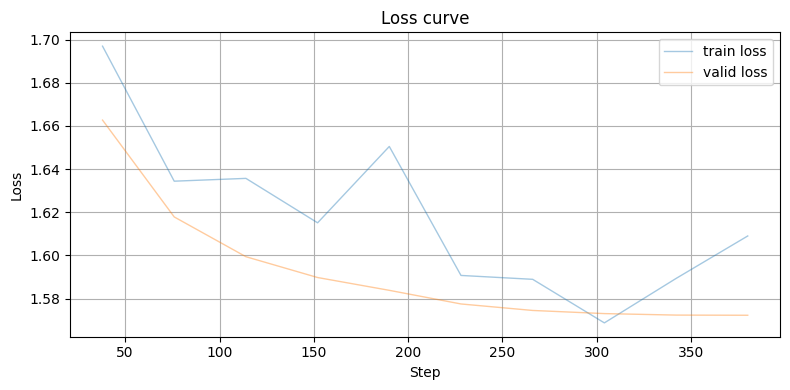

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


logs = pd.DataFrame(trainer.state.log_history)

train = logs.loc[logs["loss"].notna(), ["step", "loss"]]
valid = logs.loc[logs["eval_loss"].notna(), ["step", "eval_loss"]]

plt.figure(figsize=(8,4))
plt.plot(train["step"][1:], train["loss"][1:], label="train loss", linewidth=1, alpha=0.4)
plt.plot(valid["step"], valid["eval_loss"], label="valid loss", linewidth=1, alpha=0.4)
plt.xlabel("Step");
plt.ylabel("Loss");
plt.title("Loss curve");
plt.legend();
plt.grid(True)
plt.tight_layout();
plt.show()


In [ ]:
logs.to_csv("models/results/loss_log_gemma-3-1b-pt.csv", index=False)

In [ ]:
adapters_path = "models/gemma-3-1b-pt"

tokenizer = AutoTokenizer.from_pretrained(adapters_path,padding_side="left", use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(adapters_path,device_map='auto')
model.eval()
model.config.use_cache = True

In [ ]:
@torch.inference_mode()
def generate_pls_llama_batch(
    data,
    batch_size: int = 1,
    max_new_tokens: int = 2048,
    num_beams: int = 1,
):

    texts = data['article'].fillna("").astype(str).tolist()
    df_out = data.copy()

    max_ctx = getattr(model.config, "max_position_embeddings", 4096)
    max_input_len = max(8, max_ctx - max_new_tokens)

    outputs = []

    pbar = tqdm(total=len(texts), desc='Generando resumenes', unit="sample")
    try:
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            prompts = [generar_prompt(t) for t in batch_texts]
            enc = tokenizer(
                prompts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_input_len,
            )
            input_ids = enc["input_ids"].to(model.device)
            attention_mask = enc["attention_mask"].to(model.device)
            start = input_ids.shape[1]
            gen_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=num_beams,
                repetition_penalty=1.1,
                no_repeat_ngram_size=3,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True,
                return_dict_in_generate=False
            )

            bsz = input_ids.size(0)
            for b in range(bsz):
                out_ids = gen_ids[b, start:]
                text = tokenizer.decode(out_ids, skip_special_tokens=True,
                                        clean_up_tokenization_spaces=False).strip()
                outputs.append(text)

            pbar.update(len(batch_texts))
    finally:
      pbar.close()
    df_out['gen_summary'] = outputs
    return df_out


In [ ]:
import gc, torch


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

In [ ]:
df_test = pd.read_csv(DATA_PREPR/"data_finetuning_test.csv")
print(f'Registros totales cargados para test: {len(df_test)}')

Registros totales cargados para test: 380


In [ ]:
df_output = generate_pls_llama_batch(df_test,30)
df_output.to_csv("models/results/summaries_gemma-3-1b-pt.csv", index=False)

Generando resumenes:   0%|          | 0/380 [00:00<?, ?sample/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
